# Gibbs and Metropolis dynamics on an Ising ring

Gibbs and Metropolis-Hastings use only local energy changes and never require the partition function. Their stationary distributions agree, but their rejection rates and autocorrelation times can differ substantially.

In [1]:
CHAPTER_DIR = "ch08"
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

CWD = Path.cwd()
if CWD.name.startswith("ch"):
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / CHAPTER_DIR
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)
NODE_COLOR = "#34495e"
NODE_TEXT_COLOR = "white"
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
})

def save_figure(fig, stem):
    for suffix, kwargs in [("pdf", {}), ("png", {"dpi": 240})]:
        path = FIG_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print(f"Saved: {path}")


## Samplers

We simulate an eight-spin ferromagnetic ring. Gibbs sampling redraws one spin from its exact conditional distribution. Metropolis proposes a flip and accepts it with the standard energy-ratio rule.

accept/update fractions 1.0 0.4655111111111111


Saved: figs/ch08_02_traces_and_autocorrelation.pdf


Saved: figs/ch08_02_traces_and_autocorrelation.png


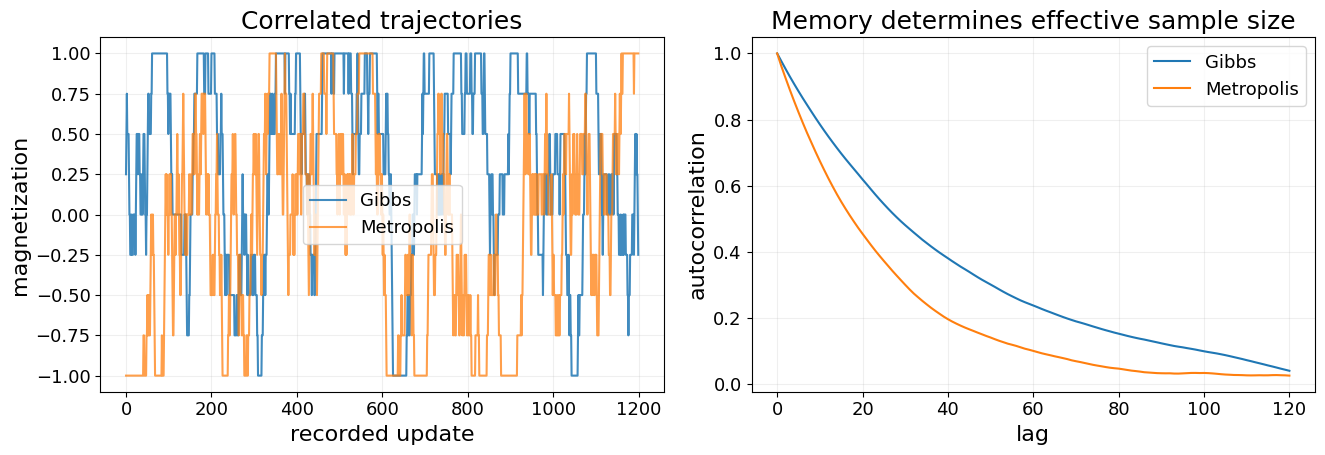

In [2]:
n=8; beta=.72; J=.8; h=.05
def logw(x): return beta*(J*sum(x[i]*x[(i+1)%n] for i in range(n))+h*np.sum(x))
def gibbs_step(x):
    i=RNG.integers(n); field=J*(x[(i-1)%n]+x[(i+1)%n])+h; p=1/(1+np.exp(-2*beta*field)); x[i]=1 if RNG.random()<p else -1; return x,True
def metro_step(x):
    i=RNG.integers(n); y=x.copy(); y[i]*=-1; a=min(1.,np.exp(logw(y)-logw(x))); ok=RNG.random()<a
    return (y if ok else x),ok
def run(step,N=45000,burn=5000):
    x=RNG.choice([-1,1],size=n); vals=[]; acc=0
    for t in range(N): x,ok=step(x); acc+=ok; vals.append(np.mean(x))
    return np.asarray(vals[burn:]),acc/N
g,ag=run(gibbs_step); m,am=run(metro_step)
print('accept/update fractions',ag,am)
def acf(y,L=120):
    y=y-y.mean(); n=len(y); m=1<<(2*n-1).bit_length(); f=np.fft.rfft(y,n=m); c=np.fft.irfft(f*np.conjugate(f),n=m)[:L+1]; c=c/np.arange(n,n-L-1,-1); return c/c[0]
fig,axes=plt.subplots(1,2,figsize=(13.5,4.8))
axes[0].plot(g[:1200],label='Gibbs',alpha=.85); axes[0].plot(m[:1200],label='Metropolis',alpha=.75); axes[0].set_xlabel('recorded update'); axes[0].set_ylabel('magnetization'); axes[0].set_title('Correlated trajectories'); axes[0].legend(); axes[0].grid(alpha=.2)
axes[1].plot(acf(g),label='Gibbs'); axes[1].plot(acf(m),label='Metropolis'); axes[1].set_xlabel('lag'); axes[1].set_ylabel('autocorrelation'); axes[1].set_title('Memory determines effective sample size'); axes[1].legend(); axes[1].grid(alpha=.2)
fig.tight_layout(); save_figure(fig,'ch08_02_traces_and_autocorrelation'); plt.show()

## Exact benchmark

Because the state space has only $2^8$ configurations, exact enumeration supplies the equilibrium magnetization distribution.

exact mean magnetization 0.11205346805456798 Gibbs 0.15019375 MH 0.11369375
Saved: figs/ch08_02_equilibrium_histogram.pdf


Saved: figs/ch08_02_equilibrium_histogram.png


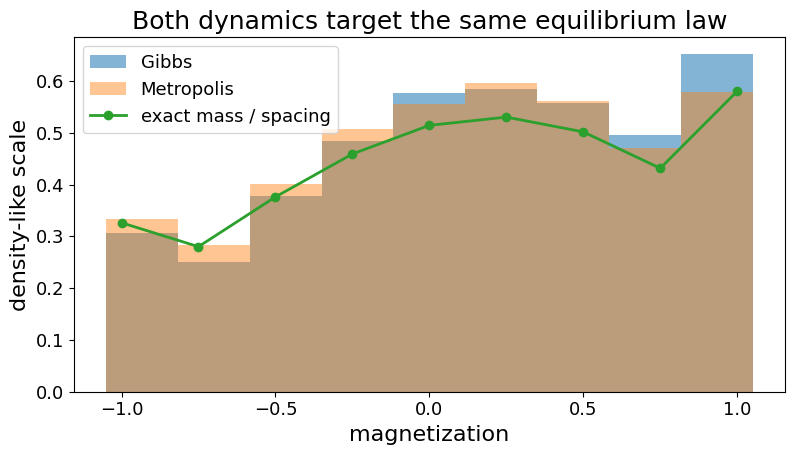

In [3]:
from itertools import product
states=np.array(list(product([-1,1],repeat=n))); w=np.exp([logw(x) for x in states]); p=w/w.sum(); exact_mean=np.sum(p*states.mean(axis=1)); print('exact mean magnetization',exact_mean,'Gibbs',g.mean(),'MH',m.mean())
fig,ax=plt.subplots(figsize=(8.2,4.8)); bins=np.linspace(-1.05,1.05,n+2); ax.hist(g,bins=bins,density=True,alpha=.55,label='Gibbs'); ax.hist(m,bins=bins,density=True,alpha=.45,label='Metropolis'); vals=np.unique(states.mean(axis=1)); exact=np.array([p[states.mean(axis=1)==v].sum() for v in vals]); ax.plot(vals,exact/(2/n),marker='o',linewidth=2,label='exact mass / spacing'); ax.set_xlabel('magnetization'); ax.set_ylabel('density-like scale'); ax.set_title('Both dynamics target the same equilibrium law'); ax.legend(); fig.tight_layout(); save_figure(fig,'ch08_02_equilibrium_histogram'); plt.show()

## Exercises

1. Estimate integrated autocorrelation times and effective sample sizes.
2. Sweep $\beta$ and identify critical slowing down on this finite ring.
3. Replace single-spin proposals by a two-spin block update.